Описова статистика


,person_age,person_income,loan_amnt,loan_status
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,44.830000,85228.15800,18649.841000,0.236000
std,14.346809,38400.69188,9845.121948,0.424835
min,20.000000,20060.00000,1097.000000,0.000000
25%,33.000000,52229.00000,10046.250000,0.000000
50%,45.000000,84850.50000,18772.500000,0.000000
75%,56.000000,118139.50000,27400.250000,0.000000
max,69.000000,149972.00000,34997.000000,1.000000


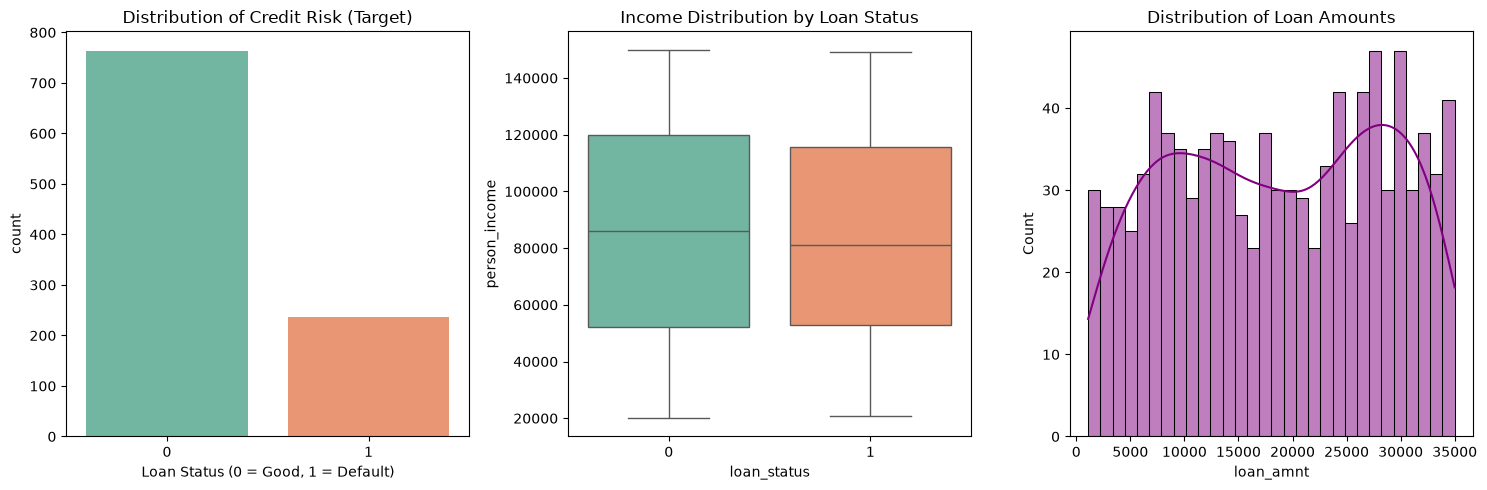

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

# 1. Load the dataset (REPLACE 'credit_risk_dataset.csv' WITH YOUR FILE PATH)
# df = pd.read_csv('credit_risk_dataset.csv')

# For demonstration, creating a dummy dataframe to simulate structure
np.random.seed(42)
df = pd.DataFrame({
    'person_age': np.random.randint(20, 70, 1000),
    'person_income': np.random.randint(20000, 150000, 1000),
    'loan_amnt': np.random.randint(1000, 35000, 1000),
    'loan_intent': np.random.choice(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE'], 1000),
    'loan_status': np.random.choice([0, 1], 1000, p=[0.78, 0.22]) # 1 = Default, 0 = Non-default
})

target_col = 'loan_status'

# --- EXPLORATORY DATA ANALYSIS (EDA) ---
print("Описова статистика")
display(df.describe())

plt.figure(figsize=(15, 5))

# Visualization 1: Target Distribution
plt.subplot(1, 3, 1)
sns.countplot(x=target_col, data=df, palette='Set2')
plt.title('Distribution of Credit Risk (Target)')
plt.xlabel('Loan Status (0 = Good, 1 = Default)')

# Visualization 2: Income Distribution (Checking for outliers)
plt.subplot(1, 3, 2)
sns.boxplot(y='person_income', x=target_col, data=df, palette='Set2')
plt.title('Income Distribution by Loan Status')

# Visualization 3: Loan Amount Histogram
plt.subplot(1, 3, 3)
sns.histplot(df['loan_amnt'], bins=30, kde=True, color='purple')
plt.title('Distribution of Loan Amounts')

plt.tight_layout()
plt.show()

In [2]:
# Identify numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(target_col)
cat_cols = df.select_dtypes(include=['object', 'category']).columns

X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target variable if it's categorical (e.g., 'Yes'/'No')
le = LabelEncoder()
y = le.fit_transform(y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- PREPROCESSING PIPELINE ---
# Impute missing values and scale outliers using RobustScaler
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()) 
])

# Impute missing categories and apply One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [3]:
# Define models and their hyperparameter grids
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {'model__C': [0.1, 1.0, 10.0]}
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {'model__var_smoothing': [1e-9, 1e-8, 1e-7]} # NB usually requires less tuning
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'model__max_depth': [5, 10, None], 'model__min_samples_split': [2, 10]}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'model__n_neighbors': [3, 5, 7], 'model__weights': ['uniform', 'distance']}
    }
}

best_models = {}
results_cv = []

print("--- Початок навчання та крос-валідації ---")
for model_name, config in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])
    
    # GridSearchCV with 5 folds
    grid = GridSearchCV(pipeline, config['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_models[model_name] = grid.best_estimator_
    results_cv.append({
        'Model': model_name,
        'Best CV F1-Score': grid.best_score_,
        'Best Params': grid.best_params_
    })
    
results_df = pd.DataFrame(results_cv)
display(results_df)

--- Початок навчання та крос-валідації ---


,Model,Best CV F1-Score,Best Params
0,Logistic Regression,0.000000,{'model__C': 0.1}
1,Naive Bayes,0.000000,{'model__var_smoothing': 1e-09}
2,Decision Tree,0.286563,"{'model__max_depth': None, 'model__min_samples..."
3,KNN,0.175325,"{'model__n_neighbors': 3, 'model__weights': 'd..."



Результати на тестовій вибірці

Модель: Logistic Regression
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       153
           1       0.00      0.00      0.00        47

    accuracy                           0.77       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.59      0.77      0.66       200

ROC-AUC: 0.5005

Модель: Naive Bayes
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       153
           1       0.00      0.00      0.00        47

    accuracy                           0.77       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.59      0.77      0.66       200

ROC-AUC: 0.5155

Модель: Decision Tree
              precision    recall  f1-score   support

           0       0.76      0.75      0.75       153
           1       0.21      0.21      0.21        47

    accuracy                           0.62  

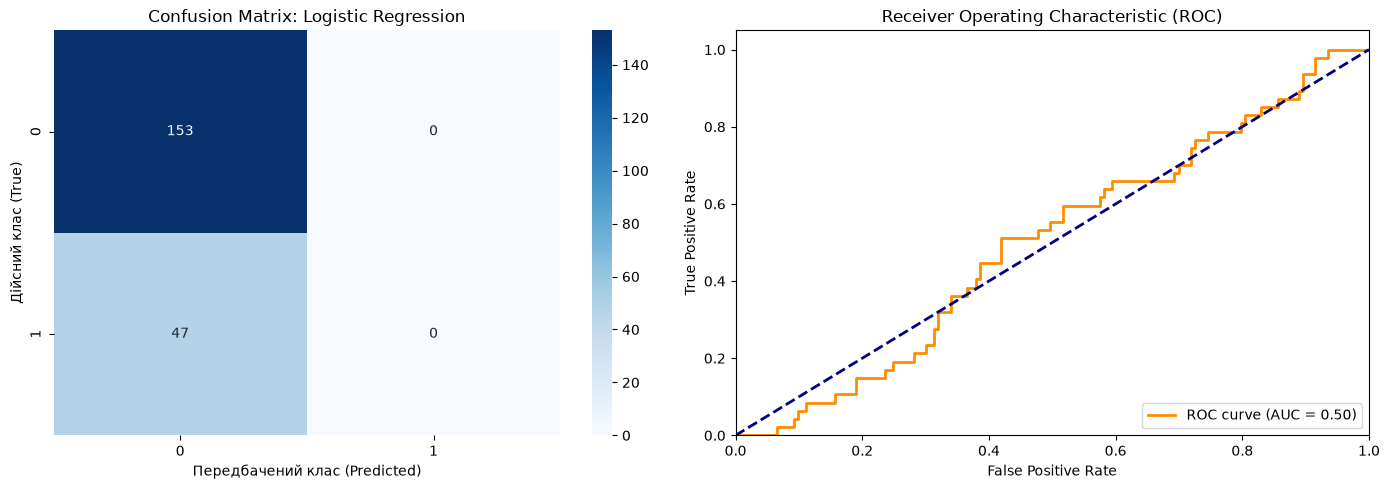

In [4]:
print("\nРезультати на тестовій вибірці")

test_results = []
for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'
    
    print(f"\nМодель: {model_name}")
    print(classification_report(y_test, y_pred))
    if auc != 'N/A': print(f"ROC-AUC: {auc:.4f}")

# Обираємо найкращу модель (наприклад, Logistic Regression) для візуалізації
best_model_name = 'Logistic Regression'
best_model = best_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# --- VISUALIZATION OF PREDICTIONS ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'Confusion Matrix: {best_model_name}')
ax[0].set_ylabel('Дійсний клас (True)')
ax[0].set_xlabel('Передбачений клас (Predicted)')

# 2. ROC Curve
y_proba_best = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba_best):.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC)')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()